# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

cars_df = pd.read_csv('data/cars_hw.csv')
cars_df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [86]:
#1
cars_df['Age'] = 2026 - cars_df['Make_Year']

X = cars_df[['Mileage_Run', 'Age']]
y = cars_df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [87]:
#2
model = LinearRegression()
model.fit(X_scaled, y)
poly.get_feature_names_out(['Mileage_Run', 'Age'])
model.coef_

array([  911774.84022262,  -248172.18553827,  -207292.62832858,
       -1671212.35639188,   350550.71987746,   -65144.89659917,
         338819.45991531,   716781.58180019,  -210037.88763612])

The interaction between Mileage_Run and "Age" is negative.

In [88]:
#3
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.462e+12, toleran

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([ 10. ...000. ])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


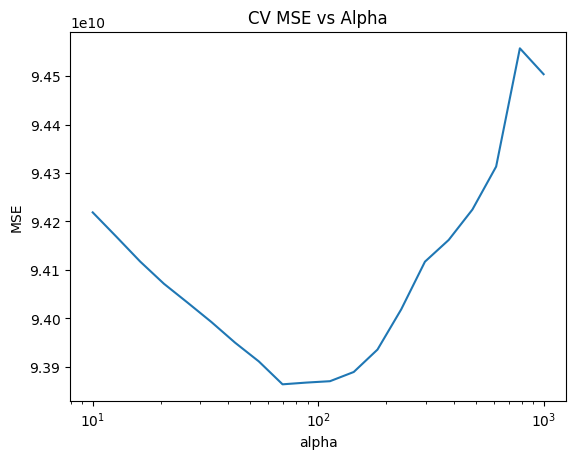

In [89]:
#4
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('CV MSE vs Alpha')
plt.show()

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.197e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.147e+13, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.085e+13, tolerance: 1.316e

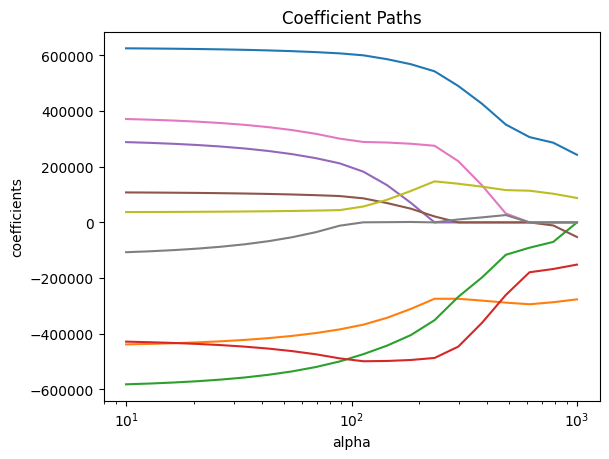

In [90]:
#5

coefs = []

for a in alphas:
    l = Lasso(alpha=a)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('Coefficient Paths')
plt.show()

In [102]:
#6
for name, coef in zip(poly.get_feature_names_out(['Mileage_Run', 'Age']), lasso.coef_):
    if coef != 0:
        print(f"{name}: {coef:.4f}")

Mileage_Run^2: -0.3261
Mileage_Run Age: 0.1174


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [92]:
heart_df = pd.read_csv('/workspace/scratchpad/data/heart_failure_clinical_records_dataset.csv')
heart_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [93]:
#1
continuous = ['age', 'ejection_fraction', 'serum_creatinine']
categorical = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

poly_cont = PolynomialFeatures(degree=3)
X_cont = poly_cont.fit_transform(heart_df[continuous])

poly_cat = PolynomialFeatures(interaction_only=True)
X_cat = poly_cat.fit_transform(heart_df[categorical])

X = np.hstack([X_cont, X_cat])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = heart_df['DEATH_EVENT']

In [94]:
#2
model = LinearRegression()
model.fit(X_scaled, y)

cont_names = poly_cont.get_feature_names_out(continuous)
cat_names = poly_cat.get_feature_names_out(categorical)
feature_names = np.concatenate([cont_names, cat_names])

for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.4f}")

1: -0.0000
age: 1.5392
ejection_fraction: -2.1925
serum_creatinine: -0.8536
age^2: -3.6787
age ejection_fraction: -0.6009
age serum_creatinine: 1.8416
ejection_fraction^2: 3.4310
ejection_fraction serum_creatinine: 2.6734
serum_creatinine^2: -2.6470
age^3: 1.9931
age^2 ejection_fraction: 0.9080
age^2 serum_creatinine: -0.6975
age ejection_fraction^2: -0.0812
age ejection_fraction serum_creatinine: -1.5777
age serum_creatinine^2: 1.2841
ejection_fraction^3: -1.2503
ejection_fraction^2 serum_creatinine: -1.2700
ejection_fraction serum_creatinine^2: 1.1795
serum_creatinine^3: 0.0722
1: -0.0000
anaemia: 0.0040
diabetes: -0.0349
high_blood_pressure: -0.0038
smoking: -0.0479
anaemia diabetes: 0.0100
anaemia high_blood_pressure: -0.0100
anaemia smoking: 0.0206
diabetes high_blood_pressure: 0.0465
diabetes smoking: 0.0469
high_blood_pressure smoking: 0.0305


In [95]:
#3
alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20)
lasso.fit(X_scaled, y)

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.016e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.807e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.068e+00, toleran

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+05])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


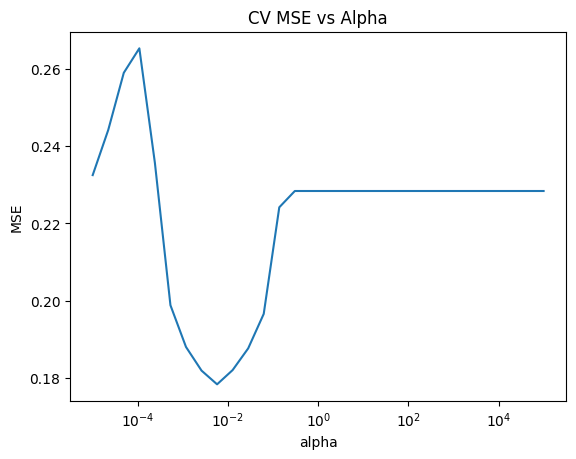

In [96]:
#4
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('CV MSE vs Alpha')
plt.show()

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.888e+01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.900e+01, tolerance: 5.874e-03
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.869e+01, toleran

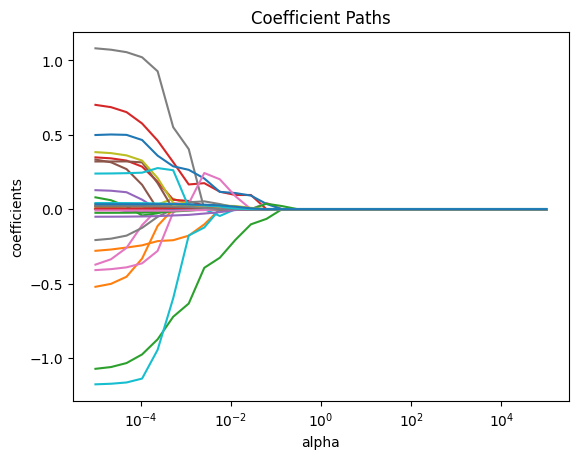

In [97]:
#5
coefs = []
for a in alphas:
    l = LassoCV(alphas=[a], cv=20)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('Coefficient Paths')
plt.show()

In [98]:
# 6
lasso.coef_

array([ 0.00000000e+00, -0.00000000e+00, -3.26123865e-01,  1.17426155e-01,
        0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  1.16214470e-01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        2.00750180e-01,  3.44194384e-02, -0.00000000e+00, -4.55579182e-02,
        0.00000000e+00,  1.31630733e-02,  0.00000000e+00,  0.00000000e+00,
       -1.98277777e-02,  3.10479275e-04, -0.00000000e+00,  0.00000000e+00,
        2.45354014e-02,  1.74103839e-02,  2.58117613e-02])

In [ ]:
#6
for name, coef in zip(feature_names, lasso.coef_):
    if coef != 0:
        print(f"{name}: {coef:.4f}")

ejection_fraction: -0.3261
serum_creatinine: 0.1174
age^3: 0.1162
ejection_fraction^3: 0.2008
ejection_fraction^2 serum_creatinine: 0.0344
serum_creatinine^3: -0.0456
anaemia: 0.0132
smoking: -0.0198
anaemia diabetes: 0.0003
diabetes high_blood_pressure: 0.0245
diabetes smoking: 0.0174
high_blood_pressure smoking: 0.0258


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. $$L = \frac{1}{n}\sum_{i=1}^{n}(\tilde{y}_i - (\tilde{b}_0 + \tilde{b}_1\tilde{x}_i))^2 + \alpha(\tilde{b}_1)^2$$


2. $$\frac{\partial L}{\partial \tilde{b}_0} = -\frac{2}{n}\sum_{i=1}^{n}(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1\tilde{x}_i) = 0$$

$$\frac{\partial L}{\partial \tilde{b}_1} = -\frac{2}{n}\sum_{i=1}^{n}\tilde{x}_i(\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1\tilde{x}_i) + 2\alpha\tilde{b}_1 = 0$$

$$\tilde{b}_0 = 0$$

$$\tilde{b}_1 = \frac{\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i\tilde{y}_i}{\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i^2 + \alpha}$$

3.  As $\alpha$ increases, the denominator gets larger, so  so $\tilde{b}_1$ shrinks toward zero but never reaches it.

4. The challenge is that $|\tilde{b}_1|$ has a sharp cusp at 0 with it being in an absolute value, it is not differentiable at $|\tilde{b}_1| = 0$, so we cannot take the derivative and set it to zero.  

Further, it is optimal to set $|\tilde{b}_1| = 0$ when  $$\left|\frac{1}{n}\sum_{i=1}^{n}\tilde{x}_i\tilde{y}_i\right| \leq \alpha$$  
This would allow the feature to be zero. If the correlation were greater than $\alpha$, then the feature IS useful enough to keep.